In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import r2_score

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=20,
    n_informative=10,
    noise=40,
    random_state=42
)

In [5]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (200, 20)
Shape of y : (200,)


In [6]:
import pandas as pd

columns = [f"Feature_{i}" for i in range(1,21)]

df = pd.DataFrame(X, columns=columns)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
0,0.198085,-0.144360,0.059218,-0.272724,-0.335785,-0.230935,0.013929,-1.503143,-0.245743,-0.054295,...,1.126565,-1.106526,-0.259591,-2.696887,-0.024125,2.573360,1.848956,1.669022,-0.268889,-245.559260
1,-0.968046,-0.310308,-0.397558,1.171718,-0.399899,1.181891,1.237654,0.182501,-0.670115,0.487560,...,-0.528297,-1.422975,-0.044893,-1.176173,0.379768,-0.970124,-0.202524,0.269295,1.036088,-24.581201
2,-0.388177,0.170416,-0.337086,-1.975467,0.056650,-1.209695,-0.613403,0.486502,0.064474,-0.144088,...,1.218762,1.490726,-0.070499,-0.939335,-0.302470,0.148667,1.530751,0.529693,-0.213443,-89.293814
3,0.513908,0.179582,1.938929,1.187679,0.403730,0.283288,-1.000331,0.324359,-1.179040,0.201160,...,-0.474904,-1.345980,-0.903702,-0.464617,-0.677745,0.126380,0.586694,-0.024196,0.871297,-115.015179
4,-0.552223,0.632932,-0.570746,0.492451,-0.049464,-0.637740,-0.832356,0.382410,0.166452,2.455300,...,-0.555477,1.189017,-1.122722,0.289169,0.471416,1.420504,-0.623141,0.674819,-0.637387,15.282627


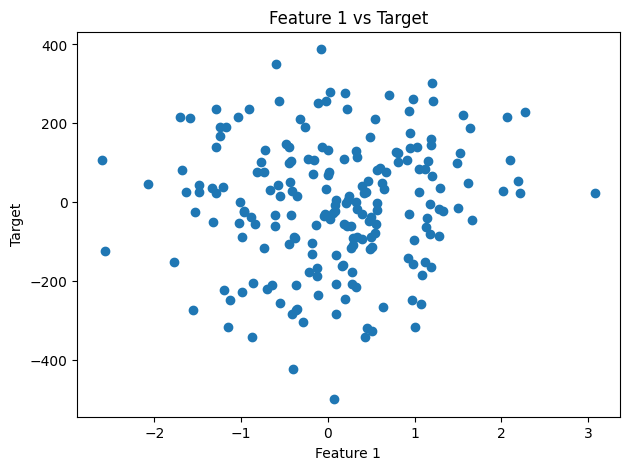

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,0], y)

plt.xlabel("Feature 1")
plt.ylabel("Target")

plt.title("Feature 1 vs Target")

plt.show()

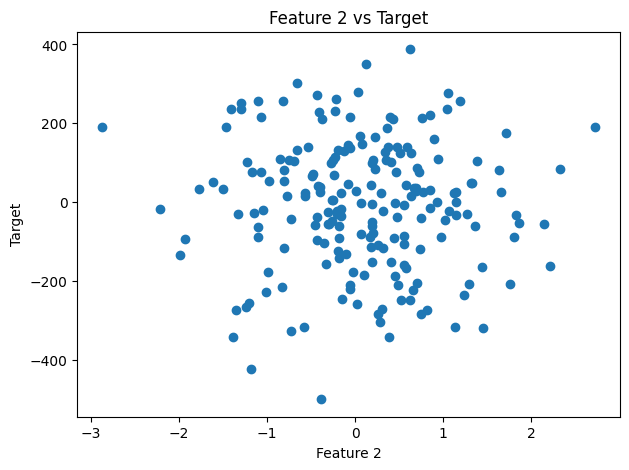

In [8]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,1], y)

plt.xlabel("Feature 2")
plt.ylabel("Target")

plt.title("Feature 2 vs Target")

plt.show()

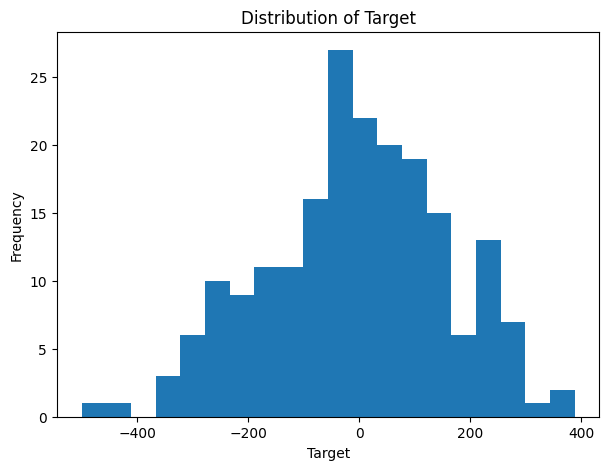

In [9]:
plt.figure(figsize=(7,5))

plt.hist(y, bins=20)

plt.title("Distribution of Target")

plt.xlabel("Target")

plt.ylabel("Frequency")

plt.show()

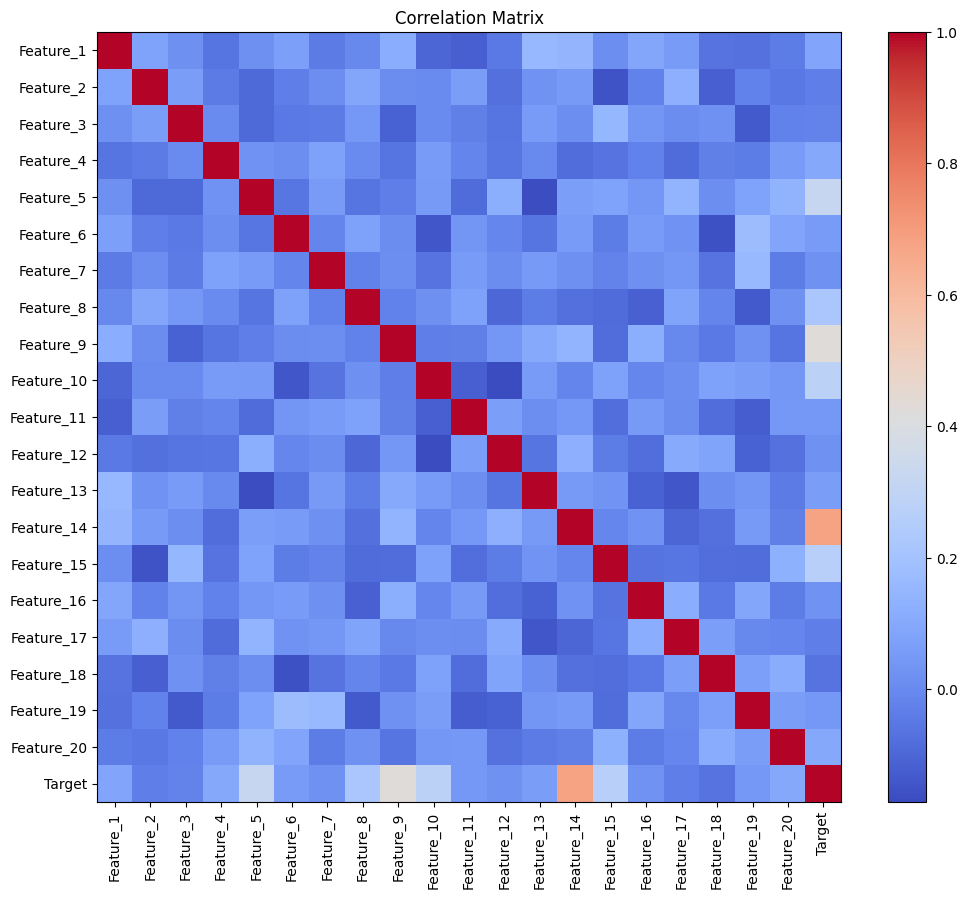

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.imshow(df.corr(), cmap='coolwarm', aspect='auto')

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")

plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 160
Testing Samples : 40


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression

In [12]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
print("Linear Regression R² Score")

print(r2_score(y_test, y_pred_lr))

Linear Regression R² Score
0.9303705456631096


# By Ridge Regression

In [16]:
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [17]:
print("Ridge Regression R² Score")

print(r2_score(y_test, y_pred_ridge))

Ridge Regression R² Score
0.9337922626059789


In [18]:
print("Linear Regression :",r2_score(y_test,y_pred_lr))

print("Ridge Regression :",r2_score(y_test,y_pred_ridge))

Linear Regression : 0.9303705456631096
Ridge Regression : 0.9337922626059789


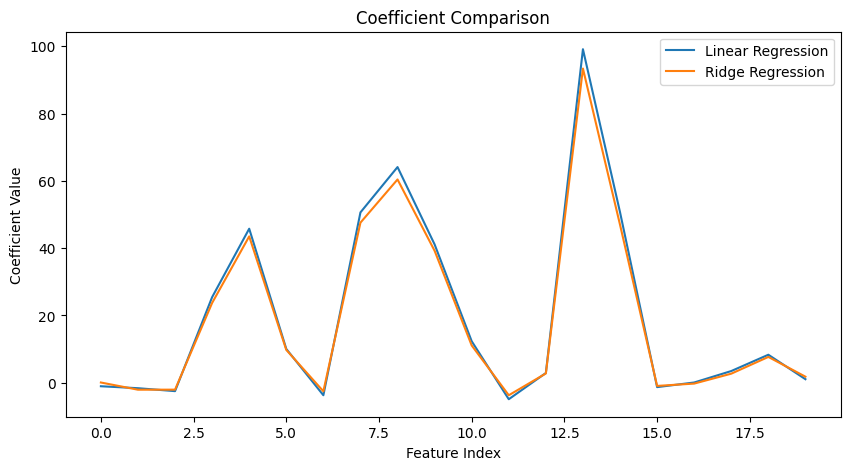

In [19]:
plt.figure(figsize=(10,5))

plt.plot(lr.coef_,label="Linear Regression")

plt.plot(ridge.coef_,label="Ridge Regression")

plt.xlabel("Feature Index")

plt.ylabel("Coefficient Value")

plt.title("Coefficient Comparison")

plt.legend()

plt.show()

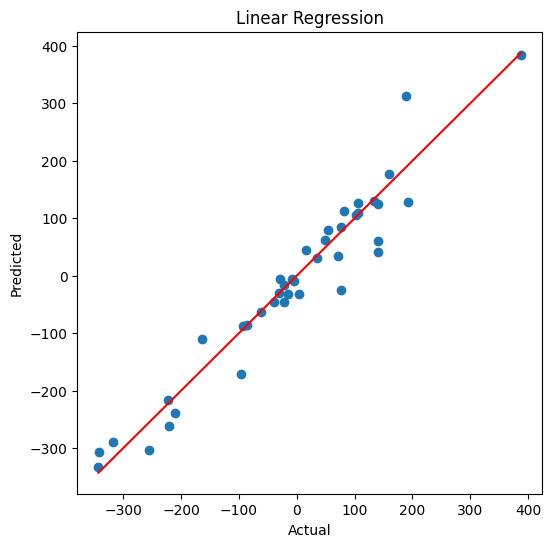

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_lr)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r'
)

plt.title("Linear Regression")

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()

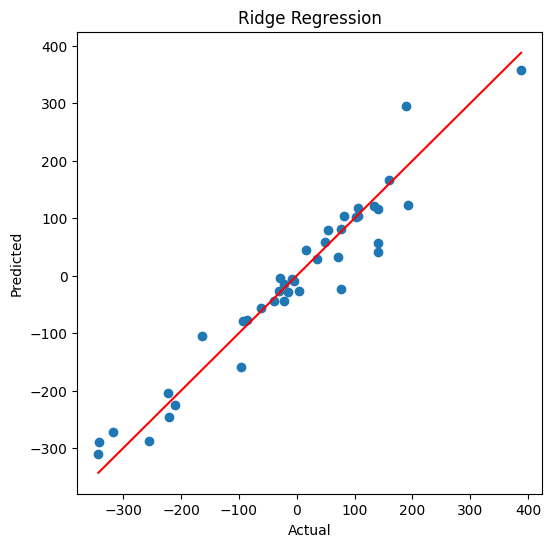

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_ridge)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r'
)

plt.title("Ridge Regression")

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()

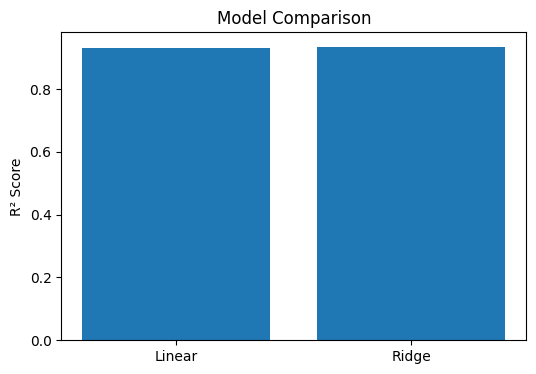

In [22]:
models = ["Linear","Ridge"]

scores = [
    r2_score(y_test,y_pred_lr),
    r2_score(y_test,y_pred_ridge)
]

plt.figure(figsize=(6,4))

plt.bar(models,scores)

plt.ylabel("R² Score")

plt.title("Model Comparison")

plt.show()

In [23]:
alphas = [0.01,0.1,1,10,100]

scores = []

for a in alphas:

    model = Ridge(alpha=a)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    scores.append(r2_score(y_test,pred))

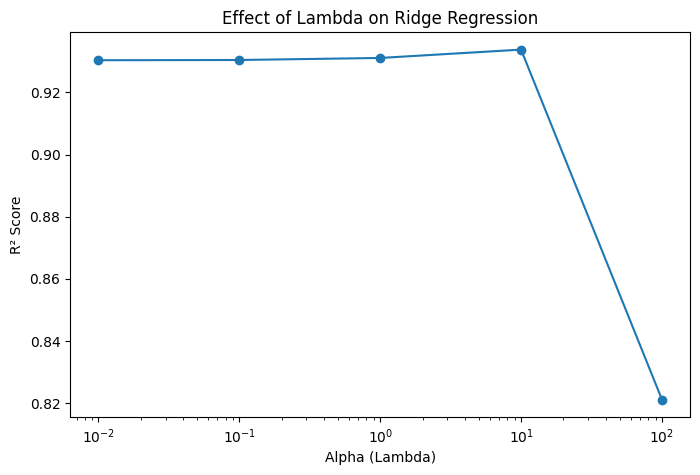

In [24]:
plt.figure(figsize=(8,5))

plt.plot(alphas,scores,marker='o')

plt.xscale("log")

plt.xlabel("Alpha (Lambda)")

plt.ylabel("R² Score")

plt.title("Effect of Lambda on Ridge Regression")

plt.show()

# Checking Overfitting And Uderfitting Using Ridge

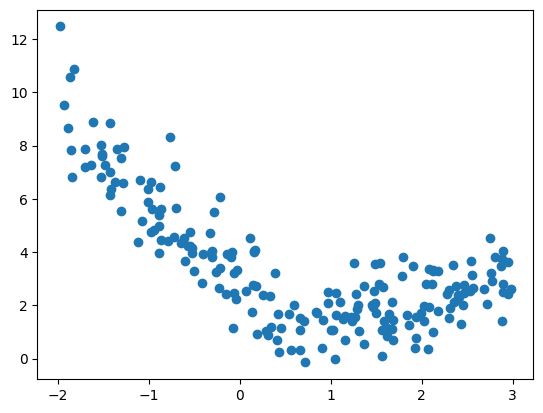

In [28]:
m = 200
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

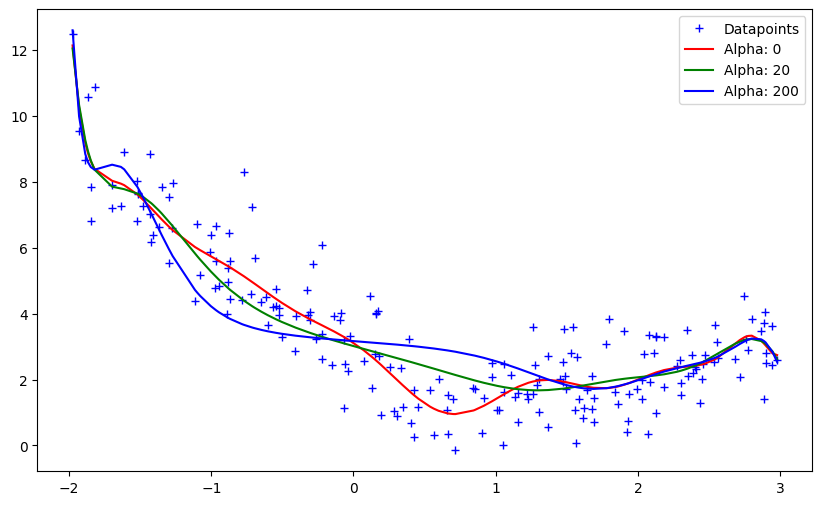

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()